In [1]:
import numpy as np 
import pandas as pd 
import os

In [2]:
dataset_path = "/kaggle/input/datasets/alenken/multimodal-emotion-recognition-ravdess/crema-d"

data = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".mp4"):
            
            file_path = os.path.join(root, file)
            
            parts = file.replace(".mp4", "").split("_")
            
            actor_id = parts[0]
            statement = parts[1]
            emotion = parts[2]
            intensity = parts[3]
            gender_code = parts[4]
            
            gender = "male" if gender_code == "01" else "female"
            
            data.append([
                file_path,
                actor_id,
                statement,
                emotion,
                intensity,
                gender
            ])

df = pd.DataFrame(data, columns=[
    "video_path",
    "actor_id",
    "statement",
    "emotion",
    "intensity",
    "gender"
])

In [3]:
df

,video_path,actor_id,statement,emotion,intensity,gender
0,/kaggle/input/datasets/alenken/multimodal-emot...,1002,IEO,FEA,LO,female
1,/kaggle/input/datasets/alenken/multimodal-emot...,1002,ITS,DIS,XX,female
2,/kaggle/input/datasets/alenken/multimodal-emot...,1002,MTI,FEA,XX,female
3,/kaggle/input/datasets/alenken/multimodal-emot...,1002,MTI,DIS,XX,female
4,/kaggle/input/datasets/alenken/multimodal-emot...,1002,WSI,NEU,XX,female
...,...,...,...,...,...,...
7437,/kaggle/input/datasets/alenken/multimodal-emot...,1042,IEO,SAD,LO,male
7438,/kaggle/input/datasets/alenken/multimodal-emot...,1042,TIE,NEU,XX,male
7439,/kaggle/input/datasets/alenken/multimodal-emot...,1042,TIE,ANG,XX,male
7440,/kaggle/input/datasets/alenken/multimodal-emot...,1042,IOM,FEA,XX,male



================ STATEMENT ================
Unique Values:
['IEO' 'ITS' 'MTI' 'WSI' 'IWL' 'IOM' 'TSI' 'DFA' 'ITH' 'TAI' 'IWW' 'TIE']

Value Counts:
statement
IEO    1456
TSI     546
IOM     546
IWL     546
TAI     546
IWW     546
DFA     546
ITS     545
TIE     545
MTI     540
WSI     540
ITH     540
Name: count, dtype: int64


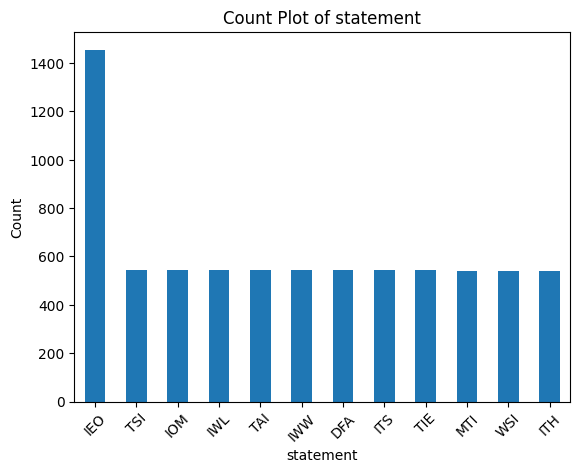

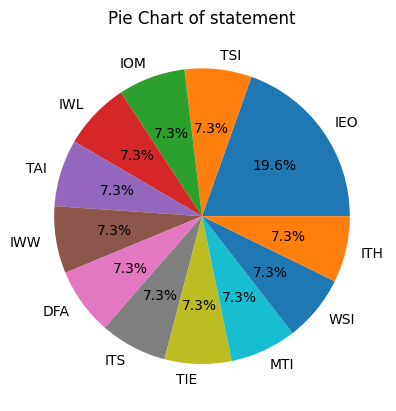


================ EMOTION ================
Unique Values:
['FEA' 'DIS' 'NEU' 'HAP' 'SAD' 'ANG']

Value Counts:
emotion
FEA    1271
DIS    1271
HAP    1271
SAD    1271
ANG    1271
NEU    1087
Name: count, dtype: int64


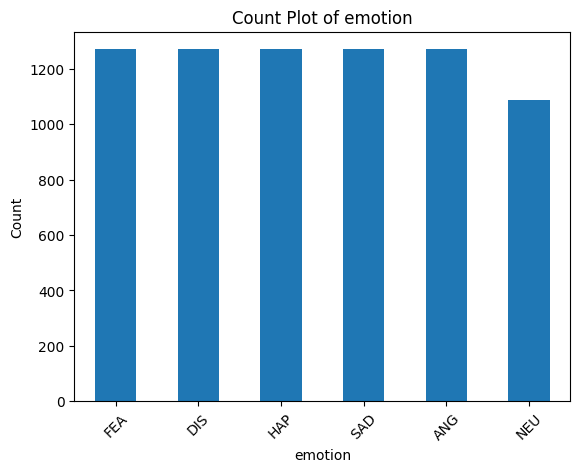

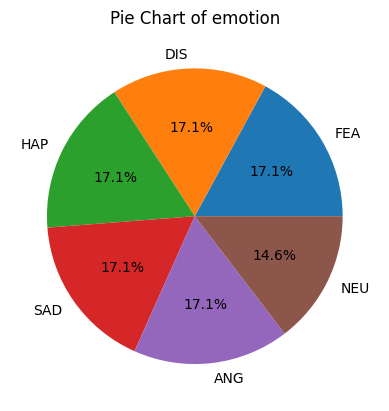


================ INTENSITY ================
Unique Values:
['LO' 'XX' 'HI' 'MD']

Value Counts:
intensity
XX    6077
LO     455
HI     455
MD     455
Name: count, dtype: int64


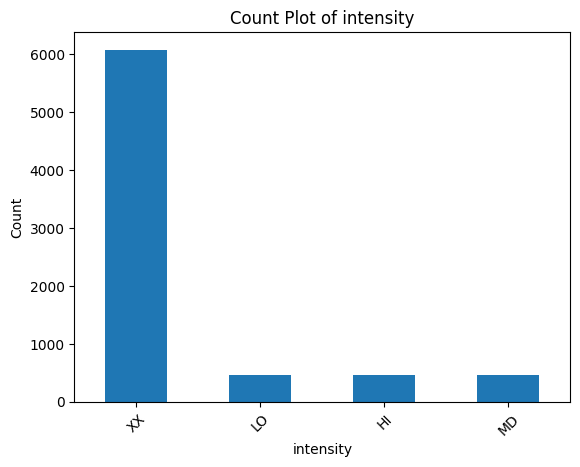

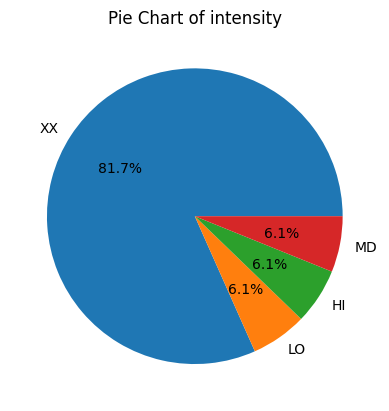


================ GENDER ================
Unique Values:
['female' 'male']

Value Counts:
gender
male      3930
female    3512
Name: count, dtype: int64


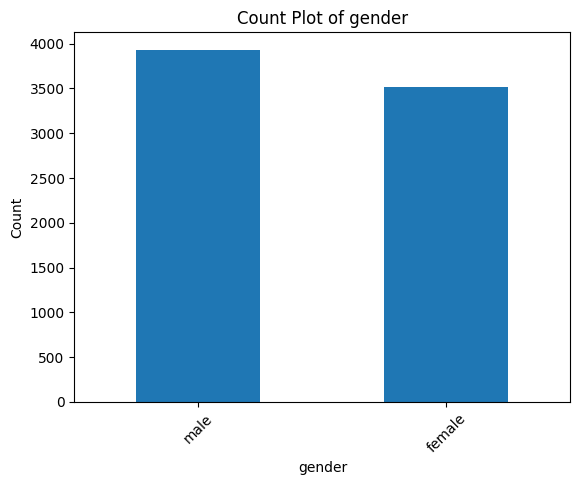

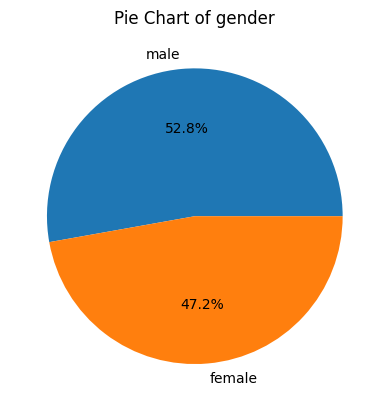

In [4]:
import matplotlib.pyplot as plt

columns = ["statement", "emotion", "intensity", "gender"]

for col in columns:
    print(f"\n================ {col.upper()} ================")
    
    # Unique values
    print("Unique Values:")
    print(df[col].unique())
    
    # Value counts
    print("\nValue Counts:")
    print(df[col].value_counts())
    
    # Count Plot (Bar Chart)
    plt.figure()
    df[col].value_counts().plot(kind="bar")
    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()
    
    # Pie Chart
    plt.figure()
    df[col].value_counts().plot(kind="pie", autopct="%1.1f%%")
    plt.title(f"Pie Chart of {col}")
    plt.ylabel("")
    plt.show()

In [5]:
import os
import pandas as pd

# Define your paths
video_root = '/kaggle/input/datasets/alenken/multimodal-emotion-recognition-ravdess/crema-d'
audio_root = '/kaggle/input/datasets/ejlok1/cremad/AudioWAV'

# Emotion mapping dictionary
emotion_map = {
    'ANG': 'angry',
    'DIS': 'disgust',
    'FEA': 'fear',
    'HAP': 'happy',
    'NEU': 'neutral',
    'SAD': 'sad'
}

# 1. Collect Audio Files
audio_data = []
for file in os.listdir(audio_root):
    if file.endswith('.wav'):
        # Key is the filename without extension: 1001_DFA_ANG_XX
        file_key = file.split('.')[0]
        audio_data.append({
            'audio_key': file_key,
            'audio_path': os.path.join(audio_root, file),
            'emotion': emotion_map.get(file_key.split('_')[2], 'Unknown')
        })

df_audio = pd.DataFrame(audio_data)

# 2. Collect Video Files (walking through subfolders)
video_data = []
for root, dirs, files in os.walk(video_root):
    for file in files:
        if file.endswith('.mp4'):
            # Video files have an extra suffix (e.g., _01), we strip it to match audio
            # 1001_DFA_ANG_XX_01 -> 1001_DFA_ANG_XX
            video_key = "_".join(file.split('_')[:-1])
            video_data.append({
                'audio_key': video_key,
                'video_path': os.path.join(root, file)
            })

df_video = pd.DataFrame(video_data)

# 3. Merge on the common key
df_multimodal = pd.merge(df_audio, df_video, on='audio_key', how='inner')

# Display result
print(f"Total multimodal pairs found: {len(df_multimodal)}")
print(df_multimodal.head())

Total multimodal pairs found: 7441
         audio_key                                         audio_path  \
0  1028_TSI_DIS_XX  /kaggle/input/datasets/ejlok1/cremad/AudioWAV/...   
1  1075_IEO_HAP_LO  /kaggle/input/datasets/ejlok1/cremad/AudioWAV/...   
2  1084_ITS_HAP_XX  /kaggle/input/datasets/ejlok1/cremad/AudioWAV/...   
3  1067_IWW_DIS_XX  /kaggle/input/datasets/ejlok1/cremad/AudioWAV/...   
4  1066_TIE_DIS_XX  /kaggle/input/datasets/ejlok1/cremad/AudioWAV/...   

   emotion                                         video_path  
0  disgust  /kaggle/input/datasets/alenken/multimodal-emot...  
1    happy  /kaggle/input/datasets/alenken/multimodal-emot...  
2    happy  /kaggle/input/datasets/alenken/multimodal-emot...  
3  disgust  /kaggle/input/datasets/alenken/multimodal-emot...  
4  disgust  /kaggle/input/datasets/alenken/multimodal-emot...  


In [6]:
df_multimodal

,audio_key,audio_path,emotion,video_path
0,1028_TSI_DIS_XX,/kaggle/input/datasets/ejlok1/cremad/AudioWAV/...,disgust,/kaggle/input/datasets/alenken/multimodal-emot...
1,1075_IEO_HAP_LO,/kaggle/input/datasets/ejlok1/cremad/AudioWAV/...,happy,/kaggle/input/datasets/alenken/multimodal-emot...
2,1084_ITS_HAP_XX,/kaggle/input/datasets/ejlok1/cremad/AudioWAV/...,happy,/kaggle/input/datasets/alenken/multimodal-emot...
3,1067_IWW_DIS_XX,/kaggle/input/datasets/ejlok1/cremad/AudioWAV/...,disgust,/kaggle/input/datasets/alenken/multimodal-emot...
4,1066_TIE_DIS_XX,/kaggle/input/datasets/ejlok1/cremad/AudioWAV/...,disgust,/kaggle/input/datasets/alenken/multimodal-emot...
...,...,...,...,...
7436,1060_IEO_ANG_MD,/kaggle/input/datasets/ejlok1/cremad/AudioWAV/...,angry,/kaggle/input/datasets/alenken/multimodal-emot...
7437,1088_IWL_ANG_XX,/kaggle/input/datasets/ejlok1/cremad/AudioWAV/...,angry,/kaggle/input/datasets/alenken/multimodal-emot...
7438,1050_IOM_ANG_XX,/kaggle/input/datasets/ejlok1/cremad/AudioWAV/...,angry,/kaggle/input/datasets/alenken/multimodal-emot...
7439,1044_IWL_SAD_XX,/kaggle/input/datasets/ejlok1/cremad/AudioWAV/...,sad,/kaggle/input/datasets/alenken/multimodal-emot...


Using device: cuda
Train samples: 5952, Test samples: 1489
Emotions: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad']


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]


Total parameters: 17,969,090
Trainable parameters: 17,969,090
Percentage trainable: 100.00%

Testing forward pass...
✓ Forward pass successful!
  Video shape: torch.Size([8, 8, 3, 224, 224])
  Audio shape: torch.Size([8, 1, 128, 128])
  Output shape: torch.Size([8, 6])

Starting training...


Validation: 100%|██████████| 187/187 [02:52<00:00,  1.09it/s]


...

  ✓ New best model saved! (val_acc: 0.8543)
Epoch 8: Train Loss: 0.1882, Train Acc: 0.9469, Val Loss: 0.6332, Val Acc: 0.8543


Validation: 100%|██████████| 187/187 [02:26<00:00,  1.28it/s]


  ✓ New best model saved! (val_acc: 0.8596)
Epoch 9: Train Loss: 0.1436, Train Acc: 0.9609, Val Loss: 0.6062, Val Acc: 0.8596


Validation: 100%|██████████| 187/187 [02:26<00:00,  1.27it/s]


Epoch 10: Train Loss: 0.1056, Train Acc: 0.9714, Val Loss: 0.6442, Val Acc: 0.8543


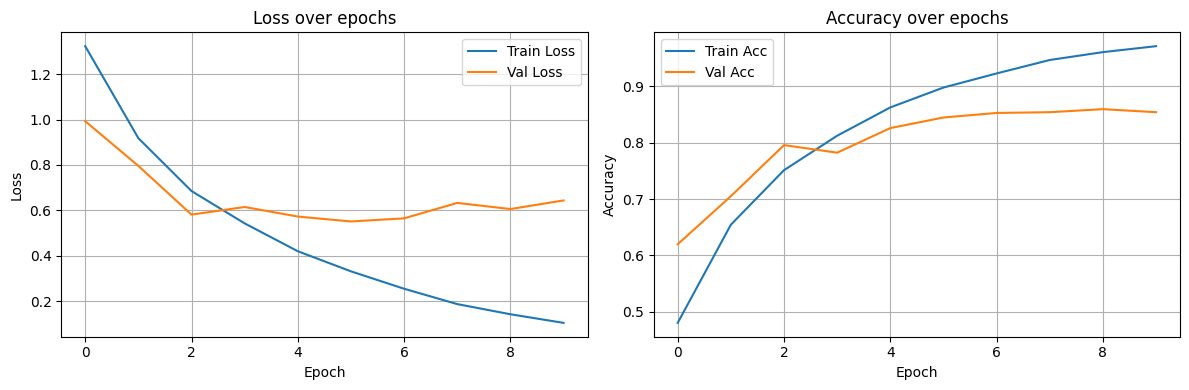


Classification Report:
              precision    recall  f1-score   support

       happy       0.86      0.93      0.89       254
     disgust       0.95      0.91      0.93       254
     neutral       0.78      0.73      0.76       255
        fear       0.95      0.97      0.96       254
       angry       0.78      0.87      0.82       218
         sad       0.79      0.72      0.75       254

    accuracy                           0.85      1489
   macro avg       0.85      0.85      0.85      1489
weighted avg       0.85      0.85      0.85      1489



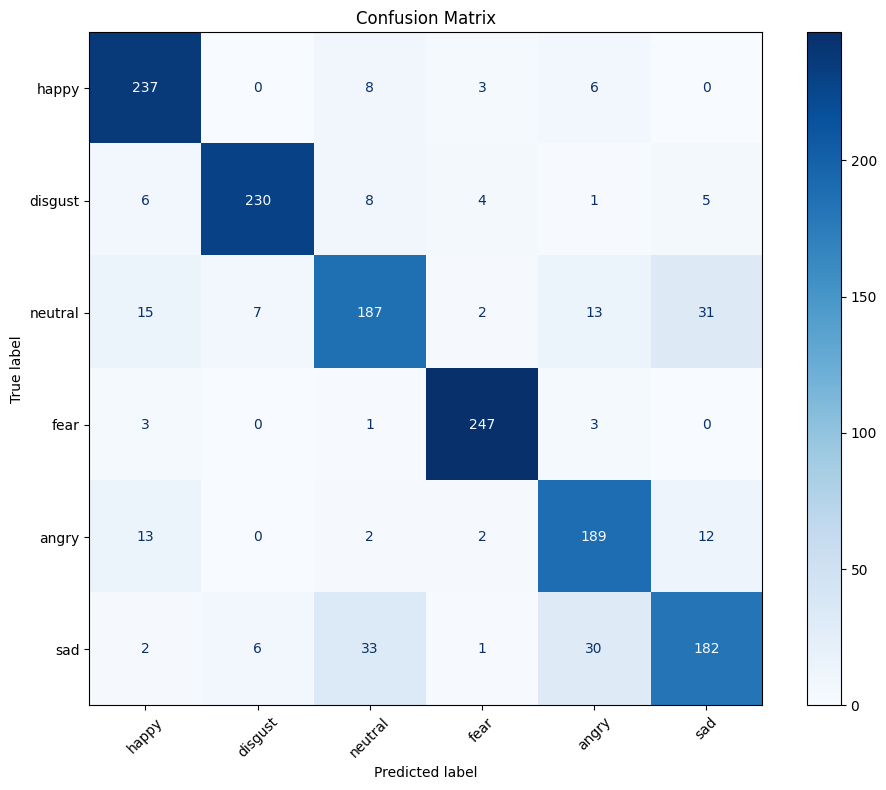

In [7]:
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import torchaudio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm
import timm
import warnings
warnings.filterwarnings('ignore')

class CremaDataset(Dataset):
    def __init__(self, df, seq_len=8, audio_duration=5):
        self.df = df
        self.seq_len = seq_len
        self.audio_duration = audio_duration
        self.target_sr = 16000
        self.audio_samples = self.target_sr * audio_duration
        
        self.emotions = sorted(df['emotion'].unique())
        self.label_map = {label: i for i, label in enumerate(self.emotions)}
        
        # Transformations vidéo
        self.video_transform = T.Compose([
            T.ToPILImage(),
            T.Resize((224, 224)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        # Transformations audio
        self.mel_spec = torchaudio.transforms.MelSpectrogram(
            sample_rate=self.target_sr,
            n_mels=128,
            n_fft=400,
            hop_length=160,
            power=2.0
        )
        
    def __len__(self):
        return len(self.df)
    
    def _get_video_frames(self, path):
        """Extrait les frames vidéo"""
        cap = cv2.VideoCapture(path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        if total_frames == 0:
            cap.release()
            return torch.zeros(self.seq_len, 3, 224, 224)
        
        # Échantillonnage uniforme
        indices = np.linspace(0, total_frames - 1, self.seq_len, dtype=int)
        frames = []
        
        for i in range(total_frames):
            ret, frame = cap.read()
            if i in indices and ret:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame_tensor = self.video_transform(frame)
                frames.append(frame_tensor)
        cap.release()
        
        # Padding si nécessaire
        while len(frames) < self.seq_len:
            frames.append(torch.zeros(3, 224, 224))
        
        return torch.stack(frames)  # [seq_len, 3, 224, 224]
    
    def _get_audio_spec(self, path):
        """Extrait le spectrogramme audio"""
        try:
            waveform, sr = torchaudio.load(path)
            
            # Convertir en mono
            if waveform.shape[0] > 1:
                waveform = torch.mean(waveform, dim=0, keepdim=True)
            
            # Resample
            if sr != self.target_sr:
                resampler = torchaudio.transforms.Resample(sr, self.target_sr)
                waveform = resampler(waveform)
            
            # Ajuster la longueur
            if waveform.shape[1] < self.audio_samples:
                padding = self.audio_samples - waveform.shape[1]
                waveform = torch.nn.functional.pad(waveform, (0, padding))
            else:
                waveform = waveform[:, :self.audio_samples]
            
            # Générer le spectrogramme Mel
            mel_spec = self.mel_spec(waveform)
            mel_spec = torchaudio.transforms.AmplitudeToDB()(mel_spec)
            
            # Redimensionner à [1, 128, 128]
            if mel_spec.shape[2] != 128:
                mel_spec = torch.nn.functional.interpolate(
                    mel_spec.unsqueeze(0), 
                    size=(128, 128)
                ).squeeze(0)
            
            return mel_spec  # [1, 128, 128]
            
        except Exception as e:
            print(f"Error loading audio {path}: {e}")
            return torch.zeros(1, 128, 128)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        video = self._get_video_frames(row['video_path'])
        audio = self._get_audio_spec(row['audio_path'])
        label = self.label_map[row['emotion']]
        
        return video, audio, label

class MultimodalLSTM(nn.Module):
    def __init__(self, num_classes, video_feat_dim=512, audio_feat_dim=512):
        super().__init__()
        
        # Backbone vidéo: EfficientNet ou ResNet
        self.video_backbone = timm.create_model(
            'efficientnet_b0', 
            pretrained=True, 
            num_classes=0,
            in_chans=3
        )
        
        # Backbone audio: ResNet18 pour spectrogrammes
        self.audio_backbone = timm.create_model(
            'resnet18', 
            pretrained=True, 
            num_classes=0,
            in_chans=1
        )
        
        # Projection layers
        self.video_proj = nn.Linear(1280, video_feat_dim)  # EfficientNet-B0 features
        self.audio_proj = nn.Linear(512, audio_feat_dim)   # ResNet18 features
        
        # LSTM pour fusion temporelle
        self.lstm = nn.LSTM(
            input_size=video_feat_dim + audio_feat_dim,
            hidden_size=256,
            num_layers=2,
            batch_first=True,
            dropout=0.2,
            bidirectional=False
        )
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, video, audio):
        """
        Args:
            video: [batch, seq_len, 3, 224, 224]
            audio: [batch, 1, 128, 128]
        """
        batch_size, seq_len = video.shape[:2]
        
        # Traitement vidéo: chaque frame indépendamment
        video_flat = video.view(-1, 3, 224, 224)  # [batch*seq_len, 3, 224, 224]
        video_features = self.video_backbone(video_flat)  # [batch*seq_len, 1280]
        video_features = self.video_proj(video_features)  # [batch*seq_len, video_feat_dim]
        video_features = video_features.view(batch_size, seq_len, -1)  # [batch, seq_len, video_feat_dim]
        
        # Traitement audio: global
        audio_features = self.audio_backbone(audio)  # [batch, 512]
        audio_features = self.audio_proj(audio_features)  # [batch, audio_feat_dim]
        
        # Répliquer audio pour chaque timestep
        audio_features = audio_features.unsqueeze(1).repeat(1, seq_len, 1)  # [batch, seq_len, audio_feat_dim]
        
        # Fusion
        combined = torch.cat([video_features, audio_features], dim=2)  # [batch, seq_len, video_feat_dim+audio_feat_dim]
        
        # LSTM
        lstm_out, _ = self.lstm(combined)  # [batch, seq_len, 256]
        
        # Dernier timestep
        final_features = lstm_out[:, -1, :]  # [batch, 256]
        
        # Classification
        output = self.classifier(final_features)
        
        return output

# Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Vérifier le dataset
if 'df_multimodal' not in dir():
    print("Error: df_multimodal not found!")
    print("Please make sure your dataframe is loaded with columns: 'video_path', 'audio_path', 'emotion'")
    exit()

# Split des données
train_df, test_df = train_test_split(
    df_multimodal, 
    test_size=0.2, 
    stratify=df_multimodal['emotion'], 
    random_state=42
)

print(f"Train samples: {len(train_df)}, Test samples: {len(test_df)}")
print(f"Emotions: {sorted(train_df['emotion'].unique())}")

# Création des datasets et dataloaders
train_dataset = CremaDataset(train_df, seq_len=8)
test_dataset = CremaDataset(test_df, seq_len=8)

train_loader = DataLoader(
    train_dataset, 
    batch_size=8, 
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=8,
    num_workers=0,
    pin_memory=True
)

# Initialisation du modèle
model = MultimodalLSTM(num_classes=len(train_df['emotion'].unique())).to(device)

# Compter les paramètres
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Percentage trainable: {100 * trainable_params / total_params:.2f}%")

# Optimizer et loss
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# Test forward pass
print("\nTesting forward pass...")
model.eval()
try:
    test_batch = next(iter(train_loader))
    video, audio, labels = [x.to(device) for x in test_batch]
    with torch.no_grad():
        outputs = model(video, audio)
        print(f"✓ Forward pass successful!")
        print(f"  Video shape: {video.shape}")
        print(f"  Audio shape: {audio.shape}")
        print(f"  Output shape: {outputs.shape}")
except Exception as e:
    print(f"✗ Forward pass failed: {e}")
    import traceback
    traceback.print_exc()
    exit()

# Entraînement
num_epochs = 10
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0

print("\n" + "="*50)
print("Starting training...")
print("="*50)

for epoch in range(num_epochs):
    # Entraînement
    model.train()
    train_loss = 0
    train_correct = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for video, audio, labels in pbar:
        video, audio, labels = video.to(device), audio.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(video, audio)
        loss = criterion(outputs, labels)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        train_correct += (outputs.argmax(1) == labels).sum().item()
        
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{train_correct / ((pbar.n + 1) * train_loader.batch_size):.4f}'
        })
    
    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = train_correct / len(train_df)
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(avg_train_acc)
    
    # Validation
    model.eval()
    val_loss = 0
    val_correct = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for video, audio, labels in tqdm(test_loader, desc="Validation"):
            video, audio, labels = video.to(device), audio.to(device), labels.to(device)
            outputs = model(video, audio)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            val_correct += (outputs.argmax(1) == labels).sum().item()
            
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_targets.extend(labels.cpu().numpy())
    
    avg_val_loss = val_loss / len(test_loader)
    avg_val_acc = val_correct / len(test_df)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(avg_val_acc)
    
    # Sauvegarde du meilleur modèle
    if avg_val_acc > best_val_acc:
        best_val_acc = avg_val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  ✓ New best model saved! (val_acc: {avg_val_acc:.4f})")
    
    print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_acc:.4f}, "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {avg_val_acc:.4f}")
    
    scheduler.step()

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_title('Loss over epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'], label='Val Acc')
axes[1].set_title('Accuracy over epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Rapport de classification
print("\n" + "="*50)
print("Classification Report:")
print("="*50)
print(classification_report(all_targets, all_preds, target_names=train_df['emotion'].unique()))

# Matrice de confusion
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    all_targets, all_preds,
    display_labels=train_df['emotion'].unique(),
    ax=ax,
    cmap='Blues'
)
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()